In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv(
    "../../out/single_token_entropy/mmlu_llama_3b.tsv",
    sep="\t",
    header=0,
    escapechar="\\",
)

df

,src,answer,options,category,question,cot_content,question_id,answer_index,total_tokens,meta_cluster,base_cluster,entropy_ans_correct,entropy_value,entropy_ans
0,ori_mmlu-jurisprudence,C,['There is no distinction between the two form...,law,Which of the following criticisms of Llewellyn...,NaN,1286,2,81,Legal Interpretation,Legal Theory Interpretations,True,1.276243,3
1,ori_mmlu-international_law,E,"['Article 19', 'Article 11', 'Article 12', 'Ar...",law,Which of the following articles are not qualif...,NaN,1293,4,38,Legal Interpretation,Constitutional Law,False,1.753829,4
2,ori_mmlu-management,D,"['Work delegation', 'Workload balancing', 'Wor...",business,As what is ensuring that one individual does n...,NaN,83,3,49,Economics & Finance MCQs,Business & Marketing Queries,True,1.984011,4
3,stemez-Business,J,"['$308.25', '$142.75', '$199.99', '$225.85', '...",business,Margaret Denault recently rented a truck to dr...,NaN,94,9,118,Economics & Finance MCQs,Business Finance Questions,False,2.054169,8
4,stemez-Business,I,"['$60,000', '$43,200', '$1,794', '$25,000', '$...",business,The tax rate in the town of Centerville is 11(...,NaN,104,8,102,Economics & Finance MCQs,Business Finance Questions,False,1.883843,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12027,ori_mmlu-high_school_macroeconomics,F,['Higher interest rates that result from borro...,economics,"The ""crowding-out"" effect refers to which of t...",NaN,7681,5,150,Economics & Finance MCQs,Economic Concepts & Policies,True,2.124042,6
12028,ori_mmlu-high_school_macroeconomics,A,['Lower reserve requirements; lower the discou...,economics,Which of the following lists contains only Fed...,NaN,7683,0,124,Economics & Finance MCQs,Economic Concepts & Policies,True,2.031201,1
12029,ori_mmlu-high_school_macroeconomics,I,['The productivity of labor in country X is 75...,economics,Output in country X is 30000 units and there a...,NaN,7684,8,206,Economics & Finance MCQs,Economic Concepts & Policies,False,2.224361,8
12030,ori_mmlu-high_school_macroeconomics,B,"['an increase in net exports', 'a decrease in ...",economics,A use of easy money (expansionary) policy by t...,NaN,7685,1,58,Economics & Finance MCQs,Economic Concepts & Policies,False,1.343410,4


In [ ]:
option_ids = [str(i + 1) for i in range(20)]
# 0 is a special exception for "do not know"
option_ids_w_fallback = option_ids + ["0"]


def validate_mmlu_answer(answer: str | int):
    return str(answer) in option_ids_w_fallback


def keep_only_valid_and_known_answers(df, column_name):
    return df[df[column_name].isin(option_ids)]

In [ ]:
df = keep_only_valid_and_known_answers(df, "entropy_ans")
df

,src,answer,options,category,question,cot_content,question_id,answer_index,total_tokens,meta_cluster,base_cluster,entropy_ans_correct,entropy_value,entropy_ans
0,ori_mmlu-jurisprudence,C,['There is no distinction between the two form...,law,Which of the following criticisms of Llewellyn...,NaN,1286,2,81,Legal Interpretation,Legal Theory Interpretations,True,1.276243,3
1,ori_mmlu-international_law,E,"['Article 19', 'Article 11', 'Article 12', 'Ar...",law,Which of the following articles are not qualif...,NaN,1293,4,38,Legal Interpretation,Constitutional Law,False,1.753829,4
2,ori_mmlu-management,D,"['Work delegation', 'Workload balancing', 'Wor...",business,As what is ensuring that one individual does n...,NaN,83,3,49,Economics & Finance MCQs,Business & Marketing Queries,True,1.984011,4
3,stemez-Business,J,"['$308.25', '$142.75', '$199.99', '$225.85', '...",business,Margaret Denault recently rented a truck to dr...,NaN,94,9,118,Economics & Finance MCQs,Business Finance Questions,False,2.054169,8
4,stemez-Business,I,"['$60,000', '$43,200', '$1,794', '$25,000', '$...",business,The tax rate in the town of Centerville is 11(...,NaN,104,8,102,Economics & Finance MCQs,Business Finance Questions,False,1.883843,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12027,ori_mmlu-high_school_macroeconomics,F,['Higher interest rates that result from borro...,economics,"The ""crowding-out"" effect refers to which of t...",NaN,7681,5,150,Economics & Finance MCQs,Economic Concepts & Policies,True,2.124042,6
12028,ori_mmlu-high_school_macroeconomics,A,['Lower reserve requirements; lower the discou...,economics,Which of the following lists contains only Fed...,NaN,7683,0,124,Economics & Finance MCQs,Economic Concepts & Policies,True,2.031201,1
12029,ori_mmlu-high_school_macroeconomics,I,['The productivity of labor in country X is 75...,economics,Output in country X is 30000 units and there a...,NaN,7684,8,206,Economics & Finance MCQs,Economic Concepts & Policies,False,2.224361,8
12030,ori_mmlu-high_school_macroeconomics,B,"['an increase in net exports', 'a decrease in ...",economics,A use of easy money (expansionary) policy by t...,NaN,7685,1,58,Economics & Finance MCQs,Economic Concepts & Policies,False,1.343410,4


<Axes: >

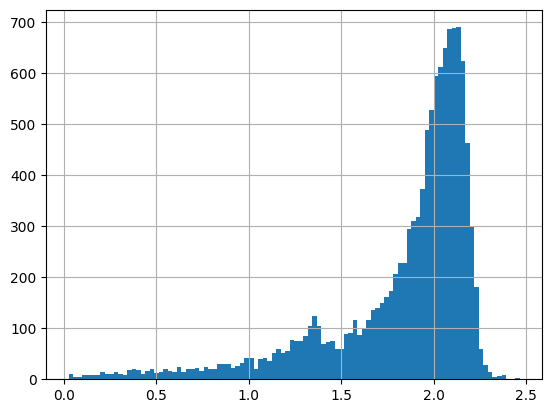

In [ ]:
df["entropy_value"].hist(bins=100)

In [ ]:
df["norm_entropy"] = df["entropy_value"] / df["entropy_value"].max()

/var/folders/62/r46p4vgs7m5bbync7hl0ykjc0000gp/T/ipykernel_59073/563240219.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['norm_entropy'] = df['entropy_value'] / df['entropy_value'].max()


In [ ]:
df["norm_entropy"].describe().round(5)

count    12030.00000
mean         0.74286
std          0.16701
min          0.01051
25%          0.69755
50%          0.80466
75%          0.85251
max          1.00000
Name: norm_entropy, dtype: float64

In [9]:
len(df[(df["norm_entropy"] >= 0.85251)])

3009

In [10]:
easy_df = df[(df["norm_entropy"] < 0.69755)]
middle_df = df[(df["norm_entropy"] >= 0.69755) & (df["norm_entropy"] < 0.85251)].sample(3008, random_state=42)
hard_df = df[(df["norm_entropy"] >= 0.85251)]

train_easy_df, test_easy_df = train_test_split(easy_df, test_size=0.1, random_state=42)
train_middle_df, test_middle_df = train_test_split(middle_df, test_size=0.1, random_state=42)
train_hard_df, test_hard_df = train_test_split(hard_df, test_size=0.1, random_state=42)

In [11]:
test_df = pd.concat([test_easy_df, test_middle_df, test_hard_df], ignore_index=True)
test_df

,src,answer,options,category,question,cot_content,question_id,answer_index,total_tokens,meta_cluster,base_cluster,entropy_ans_correct,entropy_value,entropy_ans,norm_entropy
0,stemez-Economics,H,['Investments are proportionate to the varianc...,economics,Suppose the production process is lengthy and ...,NaN,7136,7,293,Economics & Finance MCQs,Economics & Business MCQs,True,1.228818,8,0.498425
1,ori_mmlu-machine_learning,D,"['It may be used for interpretation.', 'It is ...",computer science,Which of the following sentence is FALSE regar...,NaN,10759,3,42,CS Subfield Queries,Machine Learning Queries,False,1.352145,2,0.548448
2,stemez-FluidMechanics,H,"['Q = (const) (μ/r^4) (dp/dx)', 'Q = (const) (...",engineering,"At low velocities (laminar flow), the volume f...",NaN,12065,7,518,Engineering Calculations,Heat Transfer Problems,True,1.659134,8,0.672967
3,stemez-Economics,C,"[""The monetary multiplier is the ratio of the ...",economics,"What is meant by the term ""monetary (or demand...",NaN,7133,2,238,Economics & Finance MCQs,Economics & Business MCQs,False,1.098607,8,0.445610
4,ori_mmlu-professional_medicine,H,"['Denial', 'Regression', 'Projective identific...",health,A 55-year-old man who is a business executive ...,NaN,6498,7,116,Miscellaneous,Viruses and Diseases,True,1.688545,8,0.684897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
898,stemez-Optics,J,"['2 nanoseconds', '10 nanoseconds', '5 nanosec...",physics,If the velocity of light is assumed to be 3 × ...,NaN,9245,9,86,Scientific Calculations,Wavelength & Energy Calculations,False,2.155826,9,0.874432
899,stemez-Optics,H,"['200 lines per mm', '500 lines per mm', '1200...",physics,A lens found in 35 mm cameras has a focal leng...,NaN,10282,7,166,Scientific Calculations,Wavelength & Energy Calculations,True,2.183255,8,0.885558
900,stemez-Business,I,['Sale price is $1122.58 and finance charge is...,business,A bedroom set with a list price of $1010 was a...,NaN,421,8,210,Economics & Finance MCQs,Business Finance Questions,False,2.126495,8,0.862535
901,theoremQA-Math,I,"['22', '15', '30', '18', '20', '28', '24', '17...",math,Coloring the edges of a complete graph with n ...,NaN,8627,8,62,Mathematical Problem Solving,Mathematical Computations,False,2.247739,8,0.911714


In [12]:
train_combined_df = pd.concat([train_easy_df, train_middle_df, train_hard_df], ignore_index=True)
train_combined_df

,src,answer,options,category,question,cot_content,question_id,answer_index,total_tokens,meta_cluster,base_cluster,entropy_ans_correct,entropy_value,entropy_ans,norm_entropy
0,ori_mmlu-econometrics,I,"['A pure time series model', 'A difference-in-...",economics,Consider the following equation and determine ...,NaN,7375,8,98,Statistical Analysis,Econometrics Tests and Models,False,1.166671,8,0.473218
1,ori_mmlu-world_religions,A,"['The Recitation', 'The Prophecy', 'The Revela...",philosophy,"What does the term ""Qur'an"" literally mean?",NaN,11053,0,50,Historical Trivia,Religious Origins and Beliefs,False,1.255239,3,0.509142
2,ori_mmlu-anatomy,J,"['oculomotor nerve.', 'accessory nerve.', 'tro...",health,Examination of a patient indicates that they h...,NaN,6227,9,94,Miscellaneous,Viruses and Diseases,False,1.710465,3,0.693788
3,ori_mmlu-high_school_biology,B,"['Savanna', 'Taiga', 'Tundra', 'Chaparral', 'A...",biology,This biome contains plants whose roots cannot ...,NaN,3200,1,56,Biology Questions,Biological Processes,False,1.451403,3,0.588709
4,stemez-Economics,A,['Fiscal policy is the policy of the governmen...,economics,What is fiscal policy?,NaN,7391,0,159,Economics & Finance MCQs,Economics & Business MCQs,True,0.470742,1,0.190940
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8117,stemez-TransportPhenomena,D,"['N_A = 8.0 × 10^-5 lb moles / hr, q = 0.065 B...",engineering,A vessel which contains gases A and B at 1atma...,NaN,11635,3,497,Engineering Calculations,Heat Transfer Problems,True,2.102072,4,0.852629
8118,theoremQA-Math,B,"['π', '0', '2π', '1', 'undefined', 'e (the bas...",math,What is lim_{x to 1} ((x - 1) sin((pi)/(x - 1))?,NaN,8319,1,59,Mathematical Problem Solving,Mathematical Computations,False,2.193846,5,0.889854
8119,ori_mmlu-college_biology,J,"['All dwarf white', '1 tall violet: 2 tall whi...",biology,"In garden peas, the allele for tall plants (D)...",NaN,3120,9,190,Miscellaneous,Genetics & Biology,False,2.108299,8,0.855155
8120,ori_mmlu-high_school_statistics,I,['Keeping the park open when the lead levels a...,math,The Department of Health plans to test the lea...,NaN,8120,8,217,Statistical Analysis,Statistical Questions,True,2.105713,9,0.854106


In [13]:
train_random_df = train_combined_df.sample(3008, random_state=42)

In [14]:
train_easy_df.to_csv('../entropy/llama/train_easy.tsv', sep="\t", index=False)
train_middle_df.to_csv('../entropy/llama/train_middle.tsv', sep="\t", index=False)
train_hard_df.to_csv('../entropy/llama/train_hard.tsv', sep="\t", index=False)
test_df.to_csv('../entropy/llama/test.tsv', sep="\t", index=False)
train_combined_df.to_csv('../entropy/llama/train_combined.tsv', sep="\t", index=False)
train_random_df.to_csv('../entropy/llama/train_random.tsv', sep="\t", index=False)